# **Data Processing**

### **Strict File-Level Splitting**
Before any audio manipulation occurred, the original 30-second .wav files were split into Training (80%), Validation (10%), and Testing (10%) sets. Splitting at the file level is critical; if the audio were sliced before splitting, fragments of the same song would appear in both the training and testing sets, resulting in data leakage and falsely inflated accuracy.

### **Audio Slicing and Dataset Expansion**
Because Deep Learning models require vast amounts of data, the dataset was expanded by slicing every 30-second track into ten distinct 3-second segments (sampled at 22,050 Hz). This effectively multiplied the dataset from 1,000 samples to nearly 10,000 samples, providing the model with a much larger pool of temporal patterns to learn from.

### **On-the-Fly Data Augmentation**
To improve the model's generalization and prevent it from memorizing the training data, randomized augmentations were applied exclusively to the training set during the data-loading phase. With a 50% probability, a 3-second segment would undergo:

Pitch Shifting: Shifting the harmonic frequencies up or down by 2 steps.

Additive Noise: Injecting a low level of random Gaussian white noise.

### **Mel Spectrogram Conversion**
The raw 1D audio waveforms were transformed into 2D Mel Spectrograms, effectively converting the audio classification task into an image classification task. The transformation utilized a Fast Fourier Transform (n_fft = 2048) and a hop length of 512, mapping the frequencies to 128 Mel bins. Finally, the amplitudes were converted to a decibel (dB) scale. To ensure stable tensor batching in PyTorch, the final spectrogram representations were strictly padded or truncated to a uniform dimension of 128 x 130 (Frequency Bins × Time Steps).

In [1]:
# ==========================================
# IMPORTS & ENVIRONMENT SETUP
# ==========================================

import os
import shutil
import random
import torch
import torchaudio
import torchvision
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import kagglehub
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
random.seed(42)
torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)

PyTorch version: 2.10.0+cu128
Torchaudio version: 2.10.0+cu128


In [2]:
# ==========================================
# DOWNLOAD & FILE-LEVEL SPLIT
# ==========================================

# 1. Download Dataset
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
source_dir = os.path.join(path, 'Data', 'genres_original')
target_root = 'gtzan_audio_split'
splits = ['train', 'val', 'test']

# 2. Create target directories
if os.path.exists(target_root):
    shutil.rmtree(target_root)

genres = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
for split in splits:
    for genre in genres:
        os.makedirs(os.path.join(target_root, split, genre), exist_ok=True)

# 3. Perform 80/10/10 File Split (NO SLICING YET)
print("Distributing full 30s audio files to prevent data leakage...")
stats = {split: 0 for split in splits}

for genre in genres:
    genre_path = os.path.join(source_dir, genre)
    files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]

    # Remove the corrupted jazz file if it exists
    if 'jazz.00054.wav' in files:
        files.remove('jazz.00054.wav')

    random.shuffle(files)
    n = len(files)

    # 80% Train, 10% Val, 10% Test
    train_idx = int(n * 0.8)
    val_idx = int(n * 0.9)

    file_splits = {
        'train': files[:train_idx],
        'val': files[train_idx:val_idx],
        'test': files[val_idx:]
    }

    for split, split_files in file_splits.items():
        for f in split_files:
            src = os.path.join(genre_path, f)
            dst = os.path.join(target_root, split, genre, f)
            shutil.copy(src, dst)
            stats[split] += 1

print("File split complete.")
for split, count in stats.items():
    print(f" -> {split.capitalize()} set: {count} full songs")

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Distributing full 30s audio files to prevent data leakage...
File split complete.
 -> Train set: 799 full songs
 -> Val set: 100 full songs
 -> Test set: 100 full songs


In [9]:
# ==========================================
# DATASET CLASS (3s SLICES & MEL SPECTROGRAMS)
# ==========================================

class GTZAN_3Second_Dataset(Dataset):
    def __init__(self, root_dir, split, sample_rate=22050, duration=3, augment=False):
        self.root_dir = os.path.join(root_dir, split)
        self.sample_rate = sample_rate
        self.n_samples = sample_rate * duration # 3 seconds = 66,150 frames
        self.augment = augment
        self.file_list = []

        genres = sorted(os.listdir(self.root_dir))
        self.label_to_idx = {genre: i for i, genre in enumerate(genres)}

        # Register every 3-second slice as a separate dataset item
        for genre in genres:
            genre_dir = os.path.join(self.root_dir, genre)
            for f in os.listdir(genre_dir):
                if f.endswith('.wav'):
                    full_path = os.path.join(genre_dir, f)
                    # 10 slices per 30-second track
                    for segment_idx in range(10):
                        self.file_list.append((full_path, self.label_to_idx[genre], segment_idx))

        # Define Audio Transforms
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate, n_fft=2048, hop_length=512, n_mels=128
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)

        # Define Augmentations
        self.pitch_shift = torchaudio.transforms.PitchShift(sample_rate, n_steps=2)

    def add_white_noise(self, waveform, noise_level=0.005):
        noise = torch.randn_like(waveform) * noise_level
        return waveform + noise

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path, label, segment_idx = self.file_list[idx]

        # Load exact 3-second chunk
        offset = segment_idx * self.n_samples
        try:
            waveform, sr = torchaudio.load(path, frame_offset=offset, num_frames=self.n_samples)
            if waveform.numel() == 0 or waveform.shape[1] == 0:
                waveform = torch.zeros((1, self.n_samples))
                sr = self.sample_rate
        except Exception:
            waveform = torch.zeros((1, self.n_samples))
            sr = self.sample_rate

        if sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.sample_rate)
            waveform = resampler(waveform)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        if self.augment:
            if random.random() > 0.5:
                waveform = self.pitch_shift(waveform)
            if random.random() > 0.5:
                waveform = self.add_white_noise(waveform)

        # Convert raw audio to Mel Spectrogram
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec)

        # --- THE ULTIMATE FIX ---
        # Strictly enforce the size of the output image (spectrogram).
        # 130 frames is the target width for 3s of audio with a 512 hop_length.
        target_frames = 130

        # If it's too narrow, pad it with zeros (silence)
        if mel_spec_db.shape[2] < target_frames:
            mel_spec_db = F.pad(mel_spec_db, (0, target_frames - mel_spec_db.shape[2]))
        # If it's too wide, truncate the extra frames
        else:
            mel_spec_db = mel_spec_db[:, :, :target_frames]

        return mel_spec_db, torch.tensor(label)

Total Training Samples (3s Slices): 7990
Total Validation Samples: 1000
Total Test Samples: 1000
\nBatch Shape: torch.Size([32, 1, 128, 130]) -> [Batch Size, Channels, Mels, Time Steps]


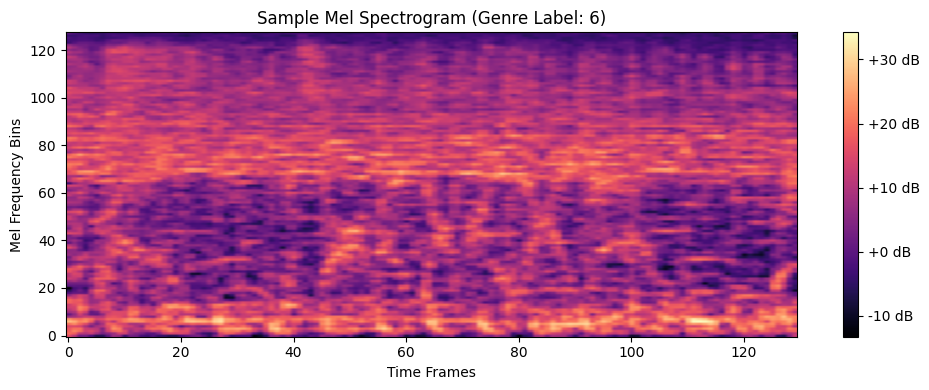

In [12]:
# ==========================================
# INITIALIZE DATALOADERS
# ==========================================

# Initialize Datasets (Notice augment=True ONLY for the training set)
train_dataset = GTZAN_3Second_Dataset(root_dir='gtzan_audio_split', split='train', augment=True)
val_dataset = GTZAN_3Second_Dataset(root_dir='gtzan_audio_split', split='val', augment=False)
test_dataset = GTZAN_3Second_Dataset(root_dir='gtzan_audio_split', split='test', augment=False)

# Initialize DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verification
mel_specs, labels = next(iter(train_loader))

print(f"Total Training Samples (3s Slices): {len(train_dataset)}")
print(f"Total Validation Samples: {len(val_dataset)}")
print(f"Total Test Samples: {len(test_dataset)}")
print(f"\\nBatch Shape: {mel_specs.shape} -> [Batch Size, Channels, Mels, Time Steps]")

# Plot a sample Mel Spectrogram to verify
plt.figure(figsize=(10, 4))
plt.imshow(mel_specs[0].squeeze().detach().numpy(), cmap='magma', origin='lower', aspect='auto')

plt.title(f"Sample Mel Spectrogram (Genre Label: {labels[0].item()})")
plt.ylabel('Mel Frequency Bins')
plt.xlabel('Time Frames')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

# **Model Architecture**

Standard Convolutional Neural Networks (CNNs) are designed for standard images, using symmetric square kernels (e.g., 3x3) that treat the X and Y axes identically. However, in a spectrogram, the Y-axis represents frequency (pitch) and the X-axis represents time (rhythm).

To address this unique physical structure, a custom Multi-Scale Spectrogram CNN is used. The architecture relies on parallel asymmetric convolutions and attention mechanisms to independently learn rhythmic and harmonic features.

### **Initial Feature Extraction**
The network begins with a standard convolutional layer (5x5 kernel, stride 2) followed by Batch Normalization and a Leaky ReLU activation. This expands the single-channel grayscale spectrogram into 32 initial feature maps while reducing the spatial dimensions to save VRAM.

### **The Multi-Scale Spectrogram Block**
The core of the architecture consists of four sequential custom blocks. Instead of a single convolution, the input tensor is passed through three parallel streams:

- Spatial Stream (3x3 kernel): Captures standard, localized acoustic textures.

- Temporal Stream (1x7 kernel): A wide, flat kernel that scans purely across the time axis to capture rhythmic patterns, drum beats, and tempo.

- Frequency Stream (7x1 kernel): A tall, narrow kernel that scans purely across the frequency axis to capture chords, harmonics, and pitch relationships.

The outputs of these three streams are concatenated back together along the channel dimension, ensuring the model simultaneously understands rhythm, harmony, and texture.

### **Squeeze-and-Excitation (SE) Attention**
After concatenation, the features pass through a Squeeze-and-Excitation (SE) Block. This is a lightweight attention mechanism that evaluates the entire feature map and mathematically "weights" the channels. If the model is analyzing a heavy metal track, the SE block might amplify the rhythmic channels; if analyzing classical music, it might amplify the harmonic channels.

### **Pooling and Classification**
After passing through four of these Multi-Scale blocks (expanding from 32 to 512 channels), the data undergoes Global Average Pooling, flattening the complex 2D spatial maps into a robust 1D vector.

Finally, the features are passed to a fully connected classification head. To combat the overfitting commonly seen in deep networks, a high Dropout rate of 50% is applied before the final linear layer, which outputs the probability distribution across the 10 GTZAN music genres.

In [13]:
# ==========================================
# THE SPECTROGRAM CNN
# ==========================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Attention Block: Learns to weight important feature channels."""
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze: Get global context of each channel
        y = self.squeeze(x).view(b, c)
        # Excitation: Calculate attention weights
        y = self.excitation(y).view(b, c, 1, 1)
        # Scale: Multiply input by attention weights
        return x * y.expand_as(x)

class MultiScaleSpectroBlock(nn.Module):
    """Custom block using parallel asymmetric convolutions for Time and Frequency."""
    def __init__(self, in_channels, out_channels):
        super(MultiScaleSpectroBlock, self).__init__()

        # Stream 1: Standard spatial features
        self.conv_standard = nn.Conv2d(in_channels, out_channels // 3, kernel_size=3, padding=1)

        # Stream 2: Temporal features (Long width, narrow height) - Captures Rhythm
        self.conv_temporal = nn.Conv2d(in_channels, out_channels // 3, kernel_size=(1, 7), padding=(0, 3))

        # Stream 3: Frequency features (Narrow width, tall height) - Captures Harmony/Pitch
        self.conv_frequency = nn.Conv2d(in_channels, out_channels - 2*(out_channels // 3), kernel_size=(7, 1), padding=(3, 0))

        self.bn = nn.BatchNorm2d(out_channels)
        self.se_block = SEBlock(out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Run parallel convolutions
        out_std = self.conv_standard(x)
        out_tmp = self.conv_temporal(x)
        out_frq = self.conv_frequency(x)

        # Concatenate features along the channel dimension
        out = torch.cat([out_std, out_tmp, out_frq], dim=1)

        # Apply Batch Norm, Activation, Attention, and Pooling
        out = self.bn(out)
        out = F.leaky_relu(out, negative_slope=0.01)
        out = self.se_block(out)
        out = self.pool(out)

        return out

class SpectroCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SpectroCNN, self).__init__()

        # Initial Convolution to expand 1 grayscale channel into 32 feature maps
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.01)
        )

        # Stack of our custom Multi-Scale blocks
        self.block1 = MultiScaleSpectroBlock(32, 64)
        self.block2 = MultiScaleSpectroBlock(64, 128)
        self.block3 = MultiScaleSpectroBlock(128, 256)
        self.block4 = MultiScaleSpectroBlock(256, 512)

        # Global Average Pooling flattens the spatial dimensions robustly
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Advanced Classifier with Dropout
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5), # High dropout to prevent overfitting on complex features
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.init_conv(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        return x

# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpectroCNN(num_classes=10).to(device)

print(f"Model initialized on: {device}")
# Calculate total parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Model initialized on: cuda
Total Trainable Parameters: 1,515,786


In [14]:
# ==========================================
# TRAINING LOOP
# ==========================================

import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

# Training hyperparameters optimized for A100/V100
EPOCHS = 40
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
# AdamW provides better weight decay than standard Adam
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# Slowly reduces learning rate to 0 by the last epoch
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_accuracies = [], []
best_val_acc = 0.0

print("Starting Advanced Training Phase...")
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping prevents "exploding gradients" in deep networks
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    # Step the learning rate scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_spectro_cnn.pth')
        checkpoint_msg = "--> Best Model Saved!"
    else:
        checkpoint_msg = ""

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}% {checkpoint_msg}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining Completed in {total_time:.2f} minutes!")
print(f"Absolute Best Validation Accuracy: {best_val_acc:.2f}%")

Starting Advanced Training Phase...
Epoch [01/40] | LR: 0.000998 | Train Loss: 1.2010 | Val Acc: 65.50% --> Best Model Saved!
Epoch [02/40] | LR: 0.000994 | Train Loss: 0.7228 | Val Acc: 75.90% --> Best Model Saved!
Epoch [03/40] | LR: 0.000986 | Train Loss: 0.5402 | Val Acc: 42.30% 
Epoch [04/40] | LR: 0.000976 | Train Loss: 0.4345 | Val Acc: 76.20% --> Best Model Saved!
Epoch [05/40] | LR: 0.000962 | Train Loss: 0.3394 | Val Acc: 85.50% --> Best Model Saved!
Epoch [06/40] | LR: 0.000946 | Train Loss: 0.2841 | Val Acc: 78.50% 
Epoch [07/40] | LR: 0.000926 | Train Loss: 0.2200 | Val Acc: 80.90% 
Epoch [08/40] | LR: 0.000905 | Train Loss: 0.1937 | Val Acc: 82.50% 
Epoch [09/40] | LR: 0.000880 | Train Loss: 0.1745 | Val Acc: 77.10% 
Epoch [10/40] | LR: 0.000854 | Train Loss: 0.1255 | Val Acc: 83.10% 
Epoch [11/40] | LR: 0.000825 | Train Loss: 0.1222 | Val Acc: 84.00% 
Epoch [12/40] | LR: 0.000794 | Train Loss: 0.0901 | Val Acc: 88.40% --> Best Model Saved!
Epoch [13/40] | LR: 0.000761 | 

Running inference on the strictly isolated Test Set...

 FINAL CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

       blues       0.76      0.91      0.83       100
   classical       0.96      1.00      0.98       100
     country       0.70      0.74      0.72       100
       disco       0.87      0.80      0.83       100
      hiphop       0.84      0.77      0.80       100
        jazz       0.84      0.86      0.85       100
       metal       0.94      0.92      0.93       100
         pop       0.77      0.74      0.76       100
      reggae       0.90      0.70      0.79       100
        rock       0.50      0.57      0.53       100

    accuracy                           0.80      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.81      0.80      0.80      1000


Generating Confusion Matrix Graphic...


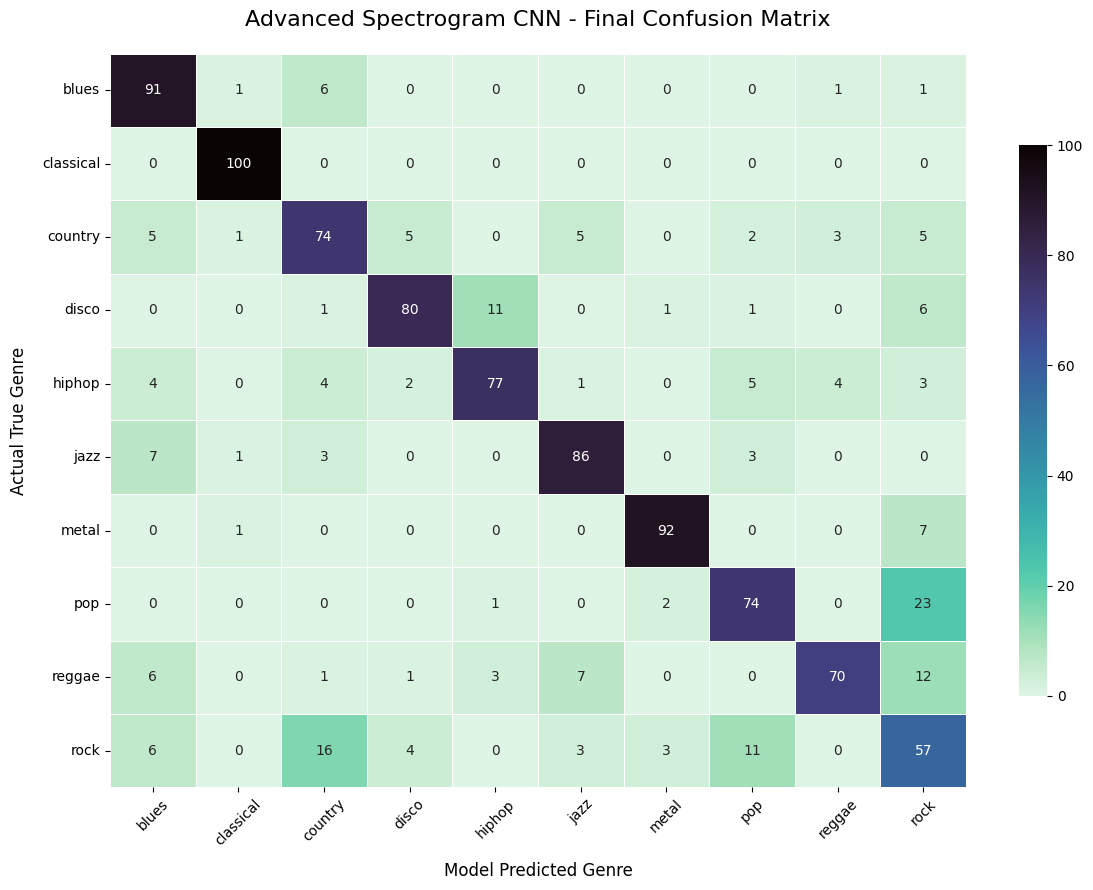

In [15]:
# ==========================================
# TEST SET EVALUATION & GRAPHICS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os

# 1. Load the absolute best weights saved during training
# (This ensures we don't just use the weights from the final epoch if it overfit slightly at the end)
model.load_state_dict(torch.load('best_spectro_cnn.pth'))
model.eval()

y_true = []
y_pred = []

print("Running inference on the strictly isolated Test Set...")

# Disable gradient tracking for faster inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Get the ordered list of genres for our labels
genres = sorted(os.listdir('gtzan_audio_split/test'))

# ==========================================
# VISUALIZATION 1: CLASSIFICATION REPORT (TABLE)
# ==========================================
print("\n" + "="*50)
print(" FINAL CLASSIFICATION REPORT (TEST SET)")
print("="*50)
# This automatically formats Precision, Recall, and F1 into a clean table
print(classification_report(y_true, y_pred, target_names=genres))

# ==========================================
# VISUALIZATION 2: CONFUSION MATRIX (HEATMAP)
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
# Using a custom color map (mako) that looks incredibly clean and professional
sns.heatmap(cm, annot=True, fmt='d', cmap='mako_r',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Advanced Spectrogram CNN - Final Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

print("\nGenerating Confusion Matrix Graphic...")
plt.show()